In [1]:
# ============================================================
# 04_category_analysis.ipynb
# Category Analysis - Core drop-off visualisation
# ============================================================
# Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from db_connection import get_engine

engine = get_engine()
print("Connected.")

Connected.


In [5]:
# Load category L1 funnel data
query_l1 = """
SELECT
    category_l1,
    COUNT(DISTINCT CASE WHEN event_type = 'view'
          THEN user_id END)                          AS users_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'cart'
          THEN user_id END)                          AS users_carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase'
          THEN user_id END)                          AS users_purchased,
    COUNT(*) FILTER (WHERE event_type = 'view')      AS total_views,
    COUNT(*) FILTER (WHERE event_type = 'purchase')  AS total_purchases,
    ROUND(
        COALESCE(SUM(price) FILTER (WHERE event_type = 'purchase'), 0),
            2) AS total_revenue,
    ROUND(
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END), 0), 2)              AS conversion_rate,
    ROUND(
        (COUNT(DISTINCT CASE WHEN event_type = 'cart'
               THEN user_id END) -
         COUNT(DISTINCT CASE WHEN event_type = 'purchase'
               THEN user_id END)) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'cart'
               THEN user_id END), 0), 2)             AS cart_abandonment_rate
FROM events_clean
WHERE category_l1 IS NOT NULL
GROUP BY category_l1
ORDER BY total_views DESC;
"""
cat_df = pd.read_sql(query_l1, engine)
print(f"Categories: {len(cat_df)}")
print(cat_df[['category_l1', 'users_viewed', 'conversion_rate',
              'cart_abandonment_rate', 'total_revenue']])

Categories: 14
     category_l1  users_viewed  conversion_rate  cart_abandonment_rate  \
0      computers        115515             8.16                  44.81   
1    electronics         89729             4.62                  40.68   
2     appliances         22373             2.48                  40.81   
3     stationery         23208             6.72                  32.66   
4           auto         17077             3.68                  44.57   
5   construction         14969             3.74                  46.10   
6      furniture          1902             3.94                  41.41   
7   country_yard          1647             1.09                  53.85   
8    accessories          1173             2.81                  38.89   
9       medicine           431             2.32                  44.44   
10          kids           265             1.51                  55.56   
11       jewelry           171             2.34                  60.00   
12         sport       

In [6]:
# Load category L2 data
query_l2 = """
SELECT
    category_l1,
    category_l2,
    COUNT(DISTINCT CASE WHEN event_type = 'view'
          THEN user_id END)                          AS users_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase'
          THEN user_id END)                          AS users_purchased,
    ROUND(
        COALESCE(SUM(price) FILTER (WHERE event_type = 'purchase'), 0),
            2) AS total_revenue,
    ROUND(
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END), 0), 2)              AS conversion_rate
FROM events_clean
WHERE category_l2 IS NOT NULL
GROUP BY category_l1, category_l2
HAVING COUNT(*) FILTER (WHERE event_type = 'view') >= 500
ORDER BY conversion_rate DESC;
"""
cat_l2_df = pd.read_sql(query_l2, engine)
print(f"L2 categories: {len(cat_l2_df)}")
print(cat_l2_df.head(10))

L2 categories: 29
   category_l1    category_l2  users_viewed  users_purchased  total_revenue  \
0    computers     components         60858             5636     3041985.35   
1    computers         ebooks          1553              132       44338.63   
2   stationery        stapler           375               30        3257.81   
3    computers    peripherals         37017             2654      545462.95   
4   stationery       cartrige         20905             1475      103595.99   
5    computers       notebook         13140              856       63604.79   
6  electronics      telephone         43843             2559      150915.69   
7  electronics         camera           993               56       20560.16   
8   appliances  steam_cleaner           640               36        8628.71   
9    computers        desktop          2994              165       25286.01   

   conversion_rate  
0             9.26  
1             8.50  
2             8.00  
3             7.17  
4      

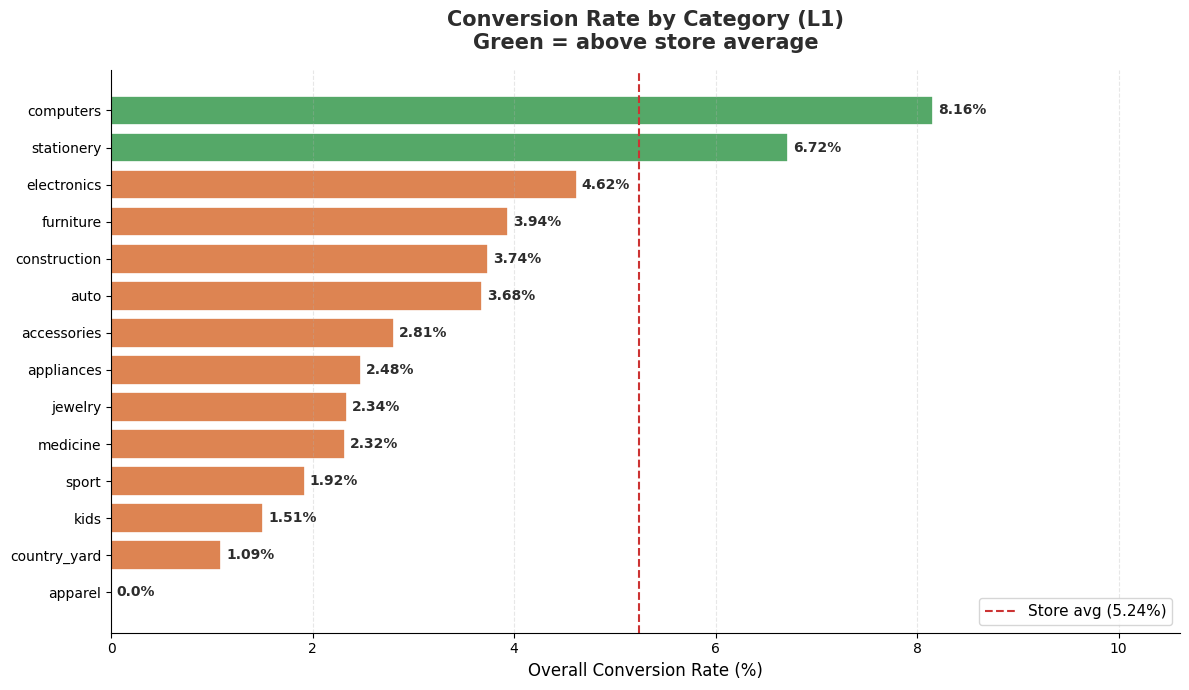

Saved.


In [7]:
# Category L1 conversion rate chart
fig, ax = plt.subplots(figsize=(12, 7))

# Sort by conversion rate
cat_sorted = cat_df.sort_values('conversion_rate', ascending=True)

colors = ['#55A868' if x >= 5.24 else '#DD8452'
          for x in cat_sorted['conversion_rate']]

bars = ax.barh(
    cat_sorted['category_l1'],
    cat_sorted['conversion_rate'],
    color=colors, edgecolor='white', linewidth=1.2
)

ax.axvline(x=5.24, color='#cc3333', linestyle='--',
           linewidth=1.5, label='Store avg (5.24%)')

for bar, val in zip(bars, cat_sorted['conversion_rate']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=10, fontweight='bold', color='#2d2d2d'
    )

ax.set_title(
    'Conversion Rate by Category (L1)\nGreen = above store average',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Overall Conversion Rate (%)', fontsize=12)
ax.set_xlim(0, max(cat_sorted['conversion_rate']) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/04_category_conversion.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

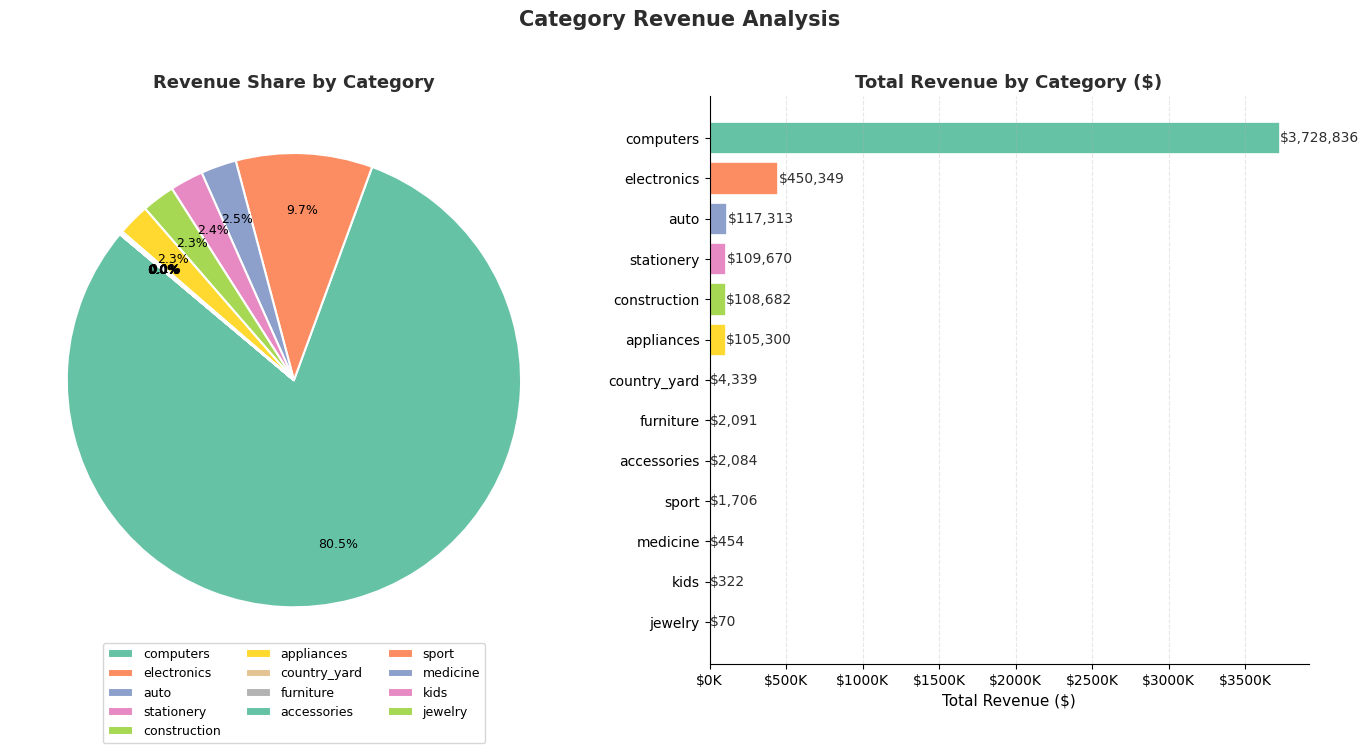

Saved.


In [12]:
# Revenue by category — pie + bar combo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Filter top categories by revenue for cleaner charts
cat_revenue = cat_df[cat_df['total_revenue'] > 0].sort_values(
    'total_revenue', ascending=False
)

# Pie chart — revenue share
wedges, texts, autotexts = ax1.pie(
    cat_revenue['total_revenue'],
    labels=None,                          
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(cat_revenue)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(9)

# Add clean legend instead
ax1.legend(
    wedges,
    cat_revenue['category_l1'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=9
)
ax1.set_title(
    'Revenue Share by Category',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)

# Bar chart — absolute revenue
bars = ax2.barh(
    cat_revenue['category_l1'][::-1],
    cat_revenue['total_revenue'][::-1],
    color=sns.color_palette('Set2', len(cat_revenue))[::-1],
    edgecolor='white', linewidth=1.2
)
for bar, val in zip(bars, cat_revenue['total_revenue'][::-1]):
    ax2.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=10, color='#2d2d2d'
    )
ax2.set_title(
    'Total Revenue by Category ($)',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax2.set_xlabel('Total Revenue ($)', fontsize=11)
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle(
    'Category Revenue Analysis',
    fontsize=15, fontweight='bold', color='#2d2d2d', y=1.02
)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/04_category_revenue.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

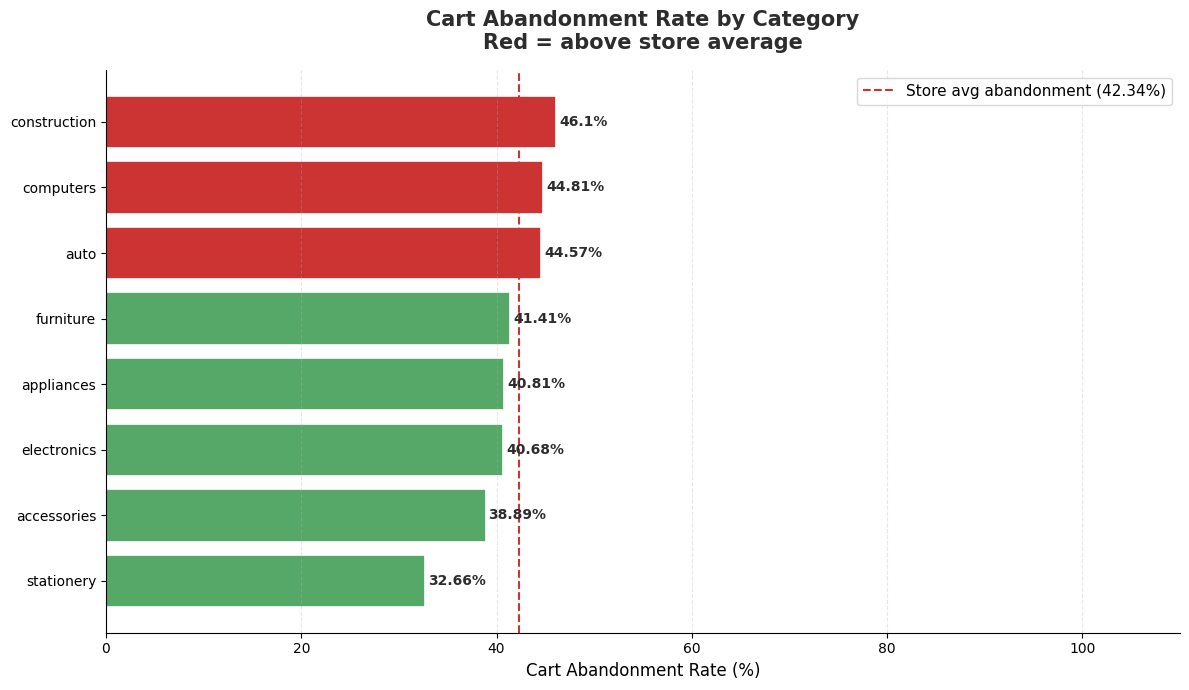

Saved.


In [10]:
# Cart abandonment by category
fig, ax = plt.subplots(figsize=(12, 7))

# Filter categories with meaningful cart volume
cat_abandon = cat_df[cat_df['users_carted'] >= 50].sort_values(
    'cart_abandonment_rate', ascending=True
)

colors = ['#cc3333' if x >= 42.34 else '#55A868'
          for x in cat_abandon['cart_abandonment_rate']]

bars = ax.barh(
    cat_abandon['category_l1'],
    cat_abandon['cart_abandonment_rate'],
    color=colors, edgecolor='white', linewidth=1.2
)

ax.axvline(x=42.34, color='#cc3333', linestyle='--',
           linewidth=1.5, label='Store avg abandonment (42.34%)')

for bar, val in zip(bars, cat_abandon['cart_abandonment_rate']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=10, fontweight='bold', color='#2d2d2d'
    )

ax.set_title(
    'Cart Abandonment Rate by Category\nRed = above store average',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Cart Abandonment Rate (%)', fontsize=12)
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/04_cart_abandonment.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

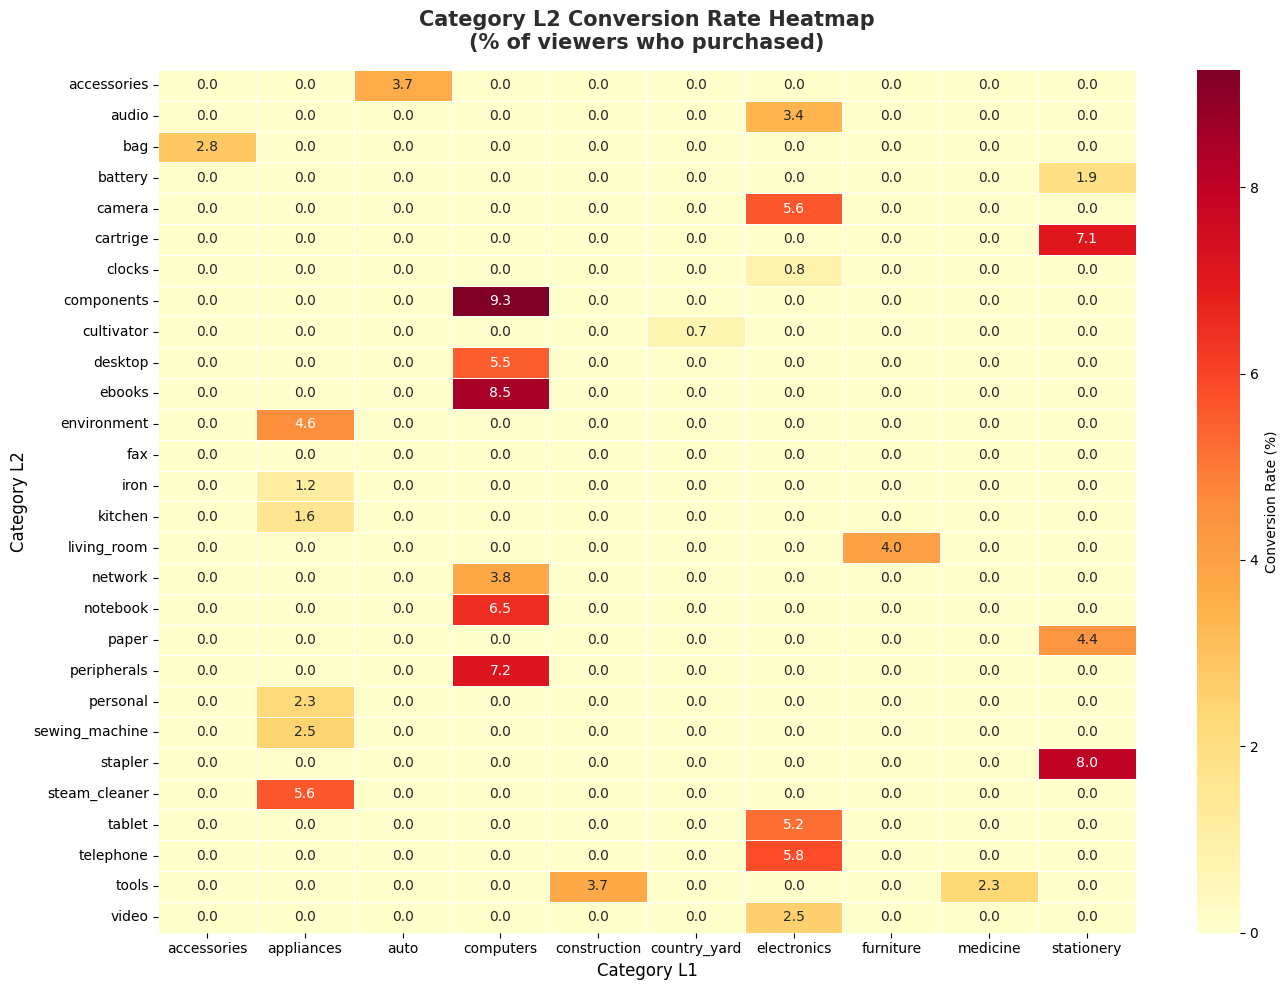

Saved.


In [11]:
# Category L2 heatmap — conversion rate
pivot = cat_l2_df.pivot_table(
    index='category_l2',
    columns='category_l1',
    values='conversion_rate',
    aggfunc='first'
).fillna(0)

# Keep only L1 categories with multiple L2 entries
pivot = pivot[pivot.columns[pivot.count() >= 2]]

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Conversion Rate (%)'}
)

ax.set_title(
    'Category L2 Conversion Rate Heatmap\n(% of viewers who purchased)',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Category L1', fontsize=12)
ax.set_ylabel('Category L2', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/04_category_heatmap.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")